In [ ]:
# import libraries
import sys
sys.path.append("../")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier


#metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve)


import warnings
warnings.filterwarnings('ignore')

from src.data_preprocessing import DataPreprocessor


print("All Libaries Imported")

All Libaries Imported


In [ ]:

# 1. Instantiate (The parentheses are crucial)
preprocessor = DataPreprocessor() 

# 2. Use the instance
from pathlib import Path
file_path = Path(r'C:\Users\Ritesh\Documents\Project\Machine Learning\Churn Prediction\Dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv')

df = preprocessor.load_data(file_path)

Loding data from C:\Users\Ritesh\Documents\Project\Machine Learning\Churn Prediction\Dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv ...
Data Loded!


In [ ]:
x_train, x_test, y_train, y_test = preprocessor.prepare_data(df)


STARTING DATA PREPROCESSING PIPELINE
Filled missing values
 Created 3 new fetures
   -tenure_group: [0 2 1 3]
   -avg_monthly_per_tenure: min = 9.18, max = 1397.47
   -num_services: min =0, max = 1
   -Encoded MultipleLines: 3 classes
   -Encoded InternetService: 3 classes
   -Encoded OnlineSecurity: 3 classes
   -Encoded OnlineBackup: 3 classes
   -Encoded DeviceProtection: 3 classes
   -Encoded TechSupport: 3 classes
   -Encoded StreamingTV: 3 classes
   -Encoded StreamingMovies: 3 classes
   -Encoded Contract: 3 classes
   -Encoded PaymentMethod: 4 classes
 Encoded 15 categorical fetures

 Train-Test split: 
    Train set : 5634 samples (80%)
    Test set : 1409 samples (20%)
FEATURES SCALED!!

 PREPROCESSING COMPLETED


In [ ]:
print("Final Dataset Summary: ")
print(f"Training samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")
print(f"Number of features: {x_train.shape[1]}")
print(f"Churn rate (train): {y_train.mean()*100:.2f}%")
print(f"Churn rate (test): {y_test.mean()*100:.2f}%")

Final Dataset Summary: 
Training samples: 5634
Test samples: 1409
Number of features: 22
Churn rate (train): 26.54%
Churn rate (test): 26.54%


# Model Training 

In [ ]:
model = {
    'Logistic Regression' : LogisticRegression(max_iter= 1000, random_state=42), 
    'Decision Tree' : DecisionTreeClassifier(max_depth=10, random_state=42), 
    'Random Forest' : RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost' : XGBClassifier(n_estimators=100, max_depth=5, random_state=42, eval_matric='logless')
}


model

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
 'Random Forest': RandomForestClassifier(max_depth=10, random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_matric='logless', eval_metric=None,
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=5, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
     

In [ ]:
# Train all models
results = {}

print("TRAINING STARTED!!\n")

for name, model in model.items():
    print(f'\nTraining started for {name}...')
    # train
    model.fit(x_train, y_train)


    # predict
    y_pred = model.predict(x_test)
    y_pred_proba = model.predict_proba(x_test)[:, 1]

    #calculate Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) 

    #Store the result
    results[name] = {
        'model' : model, 
        'accuracy' : accuracy, 
        'precision' : precision, 
        'recall' : recall,
        'f1' : f1, 
        'roc_auc' : roc_auc, 
        'y_pred' : y_pred, 
        'y_pred_proba' : y_pred_proba
    }


    print(f"{name} trained")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"ROC AUC : {roc_auc:.4f}")

print("\n\n TRAINING ENDED!!")
    

TRAINING STARTED!!


Training started for Logistic Regression...
Logistic Regression trained
Accuracy : 0.8048
ROC AUC : 0.8459

Training started for Decision Tree...
Decision Tree trained
Accuracy : 0.7615
ROC AUC : 0.7530

Training started for Random Forest...
Random Forest trained
Accuracy : 0.7970
ROC AUC : 0.8351

Training started for Gradient Boosting...
Gradient Boosting trained
Accuracy : 0.8013
ROC AUC : 0.8431

Training started for XGBoost...
XGBoost trained
Accuracy : 0.7786
ROC AUC : 0.8190


 TRAINING ENDED!!


In [ ]:
#model comparison

model_compare = pd.DataFrame({
    "Model" : list(results.keys()),
    'Accuracy' : [results[m]['accuracy'] for m in results],
    'Precision' : [results[m]['precision'] for m in results],
    'F1-Score' : [results[m]['f1'] for m in results],
    'ROC_AUC' : [results[m]['roc_auc'] for m in results],
    'Recall' : [results[m]['recall'] for m in results] ,
})

model_compare


,Model,Accuracy,Precision,F1-Score,ROC_AUC,Recall
0,Logistic Regression,0.804826,0.662295,0.594993,0.845909,0.540107
1,Decision Tree,0.761533,0.553073,0.540984,0.752992,0.529412
2,Random Forest,0.797019,0.648649,0.573134,0.835082,0.513369
3,Gradient Boosting,0.801278,0.662069,0.578313,0.843109,0.513369
4,XGBoost,0.778566,0.603333,0.537092,0.818980,0.483957


In [ ]:
model_compare = model_compare.sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

In [ ]:
print(model_compare.to_string(index=False))

              Model  Accuracy  Precision  F1-Score  ROC_AUC   Recall
Logistic Regression  0.804826   0.662295  0.594993 0.845909 0.540107
  Gradient Boosting  0.801278   0.662069  0.578313 0.843109 0.513369
      Random Forest  0.797019   0.648649  0.573134 0.835082 0.513369
            XGBoost  0.778566   0.603333  0.537092 0.818980 0.483957
      Decision Tree  0.761533   0.553073  0.540984 0.752992 0.529412


In [ ]:
# Save the comparison in excel form
model_compare.to_csv('../Report/model_comparision.csv', index = False)
print("Saved: Model Comparison file in reports")

Saved: Model Comparison file in reports


## Model Visulisation




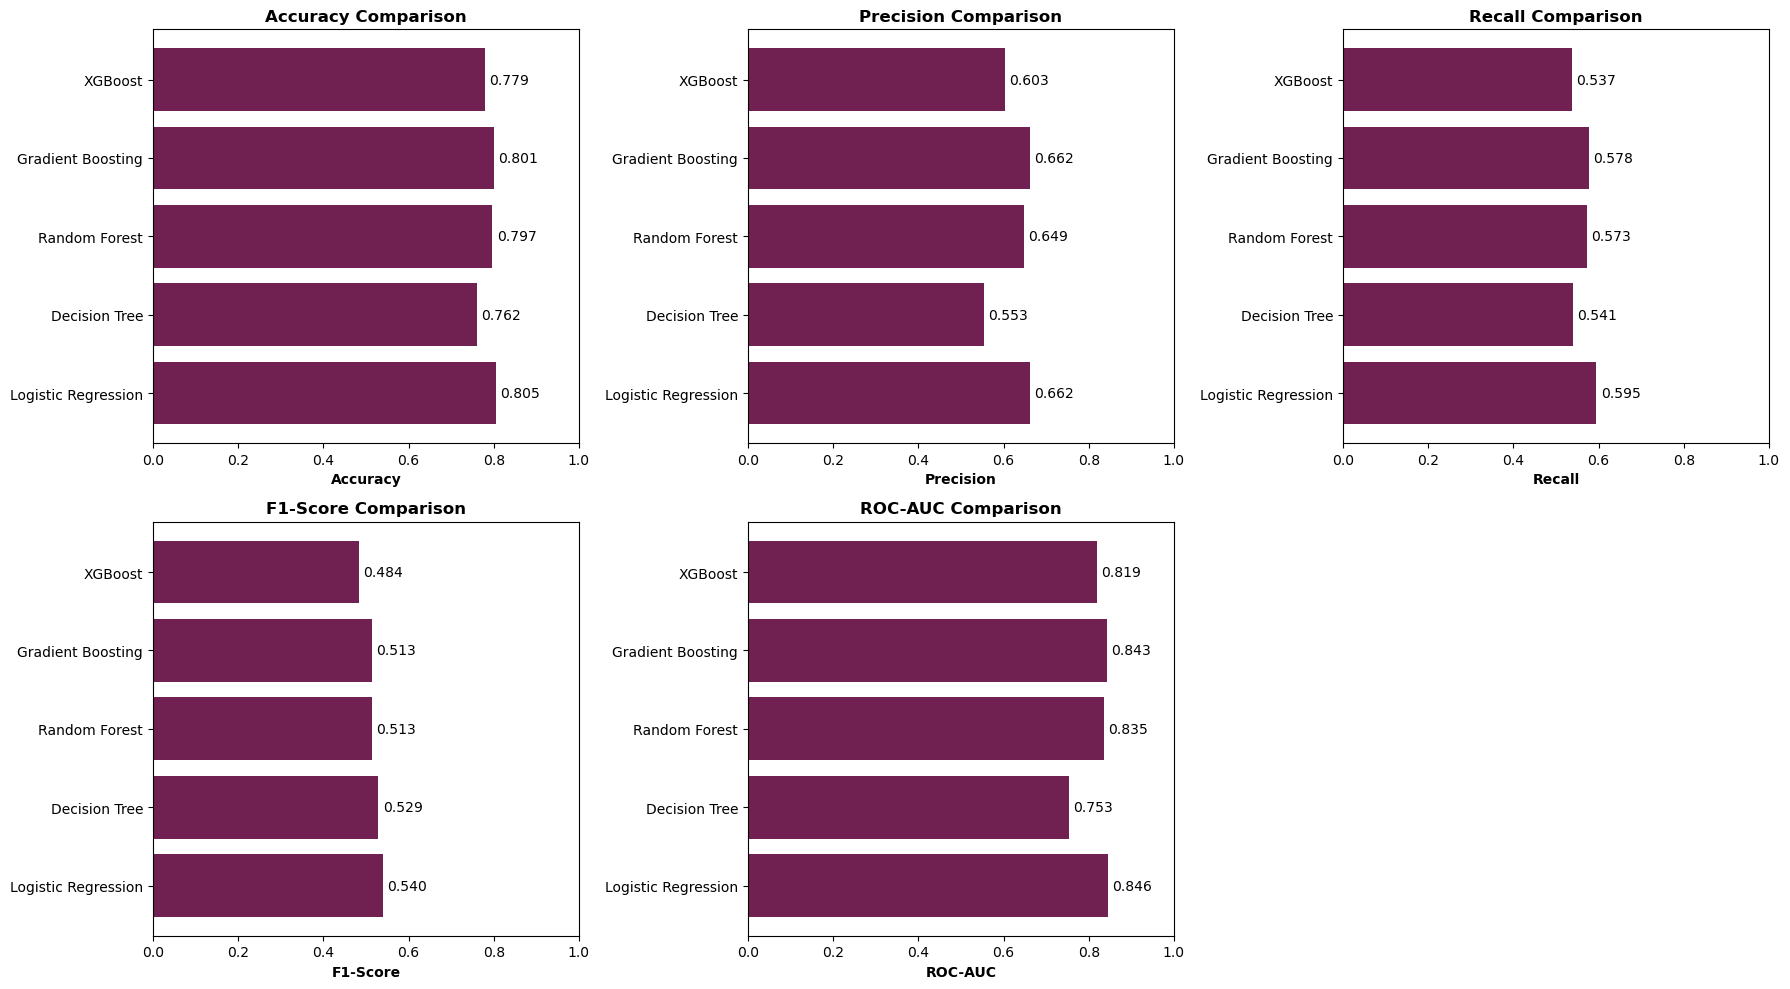

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics = ['accuracy', 'precision', 'f1', 'recall', 'roc_auc']
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for idx, (metric, metric_name) in enumerate(zip(metrics, metrics_names)):
    
    values = [results[m][metric] for m in results]
    model_names = list(results.keys())

    axes[idx].barh(model_names, values, color = '#702152')
    axes[idx].set_xlabel(metric_name, fontweight='bold')
    axes[idx].set_xlim(0, 1)
    axes[idx].set_title(f'{metric_name} Comparison', fontweight='bold')


    for i, v in enumerate(values):
        axes[idx].text(v + 0.01, i, f'{v:.3f}', va='center')

fig.delaxes(axes[5])
plt.tight_layout()

#save
plt.savefig('../Report/model_comparision_graph.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
best_model_name = model_compare.iloc[0]['Model']
best_model_result = results[best_model_name]

#best_model_name, best_model_result

print(f"Best Model : {best_model_name}")

Best Model : Logistic Regression


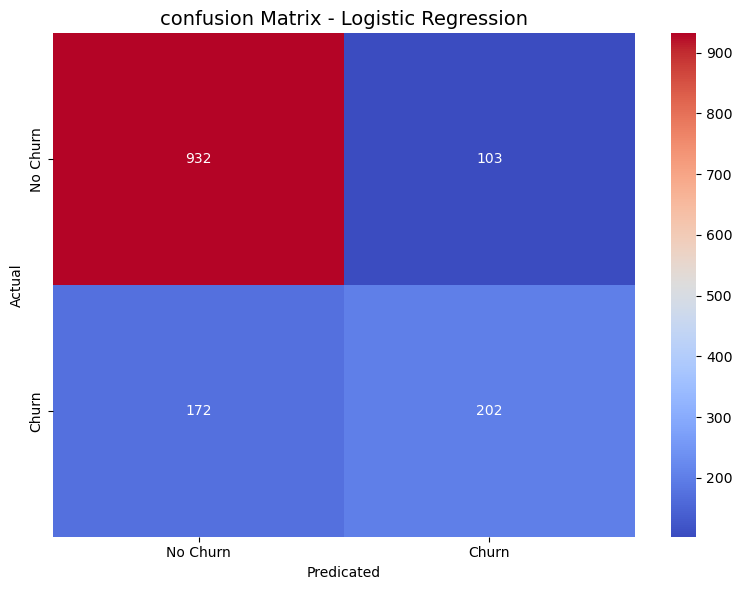

saved : Report/confusion_matrics.png


In [ ]:
cm = confusion_matrix(y_test, best_model_result['y_pred'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
xticklabels=['No Churn', 'Churn'], 
yticklabels=['No Churn', 'Churn'])

plt.title(f'confusion Matrix - {best_model_name}', fontsize=14, fontweight='14')
plt.ylabel('Actual')
plt.xlabel('Predicated')


plt.tight_layout()
plt.savefig('../Report/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("saved : Report/confusion_matrics.png")